# Plotagem dos resultados de avaliacao

Este notebook le os CSVs gerados por `tools/eval/run_eval.py` e salva os mesmos graficos de `tools/eval/plot.py` em `figs/` dentro da pasta de resultados.

Quando a bateria tem mais de um ladrão, os gráficos comparam por `thief_agent`. Quando tem um ladrão e vários detetives, comparam por `detective_agent`.


## Configuracao

In [13]:
# Imports
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
FIGSIZE = (4, 3)


In [14]:
# Parametros de entrada
def find_project_root(start: Path = Path.cwd()) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "tools/eval/run_eval.py").is_file():
            return candidate
    raise FileNotFoundError(f"Raiz do projeto nao encontrada a partir de {start}")


def latest_result_dir(base: Path) -> Path:
    candidates = [p for p in base.iterdir() if (p / "matches.csv").is_file()]
    if not candidates:
        raise FileNotFoundError(f"Nenhuma pasta de resultado encontrada em {base}")
    return max(candidates, key=lambda p: (p / "matches.csv").stat().st_mtime)


PROJECT_ROOT = find_project_root()
RESULTS_BASE = PROJECT_ROOT / "tools/eval/results"

# Para usar uma bateria especifica, substitua por algo como:
# RESULT_DIR = RESULTS_BASE / "mapa1__randomt-thief__vs__randomd__n50__seed1__..."
RESULT_DIR = latest_result_dir(RESULTS_BASE)

FIGS_DIR = RESULT_DIR / "figs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

RESULT_DIR, FIGS_DIR


(PosixPath('/home/lucas/dev/web/agents/tools/eval/results/cenario1__thief-thiefnew__vs__randomd__n50__seed1__184022daae76'),
 PosixPath('/home/lucas/dev/web/agents/tools/eval/results/cenario1__thief-thiefnew__vs__randomd__n50__seed1__184022daae76/figs'))

In [15]:
# Helpers equivalentes aos de tools/eval/plot.py
def load_dataset(result_dir: Path):
    """Carrega os CSVs de uma bateria em um dict de DataFrames."""
    result_dir = Path(result_dir).resolve()
    paths = {
        "matches": result_dir / "matches.csv",
        "summary": result_dir / "summary.csv",
        "best_worst": result_dir / "best_worst.csv",
    }
    missing = [str(path) for path in paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "CSVs ausentes: " + ", ".join(missing) +
            f"\nCWD: {Path.cwd()}\nRESULT_DIR: {result_dir}"
        )

    data = {name: pd.read_csv(path) for name, path in paths.items()}
    normalize_frames(data["matches"], data["summary"], data["best_worst"])
    return data


def normalize_frames(matches: pd.DataFrame, summary: pd.DataFrame, best_worst: pd.DataFrame) -> None:
    for frame in [matches, summary, best_worst]:
        for col in ["thief_agent", "detective_agent", "scenario"]:
            if col in frame.columns:
                frame[col] = frame[col].astype(str)

    if "winner" in matches.columns:
        matches["winner"] = matches["winner"].map({
            "ladrao": "thief",
            "detetive": "detective",
            "empate": "draw",
        }).fillna(matches["winner"])


def save_fig(name: str) -> None:
    plt.tight_layout()
    path = FIGS_DIR / name
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(path)


def without_all(summary: pd.DataFrame) -> pd.DataFrame:
    if "detective_agent" not in summary.columns:
        return summary
    filtered = summary[summary["detective_agent"] != "ALL"]
    return filtered if not filtered.empty else summary


def comparison_axis(frame: pd.DataFrame):
    if "thief_agent" in frame.columns and frame["thief_agent"].nunique() > 1:
        return "thief_agent", "Ladrao"
    return "detective_agent", "Detetive"


In [16]:
# Carregamento dos CSVs
dataset = load_dataset(RESULT_DIR)
matches = dataset["matches"]
summary = dataset["summary"]
best_worst = dataset["best_worst"]

display(summary)
display(matches.head())


,thief_agent,detective_agent,scenario,rounds,score_mean,score_best,score_worst,win_rate,draw_rate,loss_rate,turns_mean,robberies_mean,real_revealed_attrs_mean,risk_mean,no_progress_moves_mean,best_run_id,worst_run_id
0,agents/thief.pl,agents/randomd.pl,src/engine/cenario1.prolog,50,-155.3,535.0,-495.0,0.04,0,0.96,8.86,2.58,5.38,0.80,1.20,82bf48e3e4edea13,e0efbd1edc3c6aa7
1,agents/thief.pl,ALL,src/engine/cenario1.prolog,50,-155.3,535.0,-495.0,0.04,0,0.96,8.86,2.58,5.38,0.80,1.20,82bf48e3e4edea13,e0efbd1edc3c6aa7
2,agents/thiefnew.pl,agents/randomd.pl,src/engine/cenario1.prolog,50,-103.2,570.0,-460.0,0.14,0,0.86,9.30,3.22,7.64,1.34,0.42,cfc7ec9bd8a130ce,a6490ee993b9ac6d
3,agents/thiefnew.pl,ALL,src/engine/cenario1.prolog,50,-103.2,570.0,-460.0,0.14,0,0.86,9.30,3.22,7.64,1.34,0.42,cfc7ec9bd8a130ce,a6490ee993b9ac6d


,run_id,round,seed,scenario,thief_agent,detective_agent,winner,won,draw,lost,...,recent_revealed_city_turns,mandate_risk_events,no_progress_moves,illegal_actions,disguises_used,thief_start,detective_start,thief_id,target,loss_reason
0,bc54cf704e47694c,1,1,src/engine/cenario1.prolog,agents/thief.pl,agents/randomd.pl,detective,0,0,1,...,0,2,3,0,0,c,h,9,diamante_azul,closed_city
1,028b31e72de22a78,2,2,src/engine/cenario1.prolog,agents/thief.pl,agents/randomd.pl,detective,0,0,1,...,0,1,2,0,0,b,j,9,diamante_azul,closed_city
2,d3fb5458ed9fc584,3,3,src/engine/cenario1.prolog,agents/thief.pl,agents/randomd.pl,detective,0,0,1,...,0,0,1,0,0,g,e,9,diamante_azul,closed_city
3,3bbffb011b517cdb,4,4,src/engine/cenario1.prolog,agents/thief.pl,agents/randomd.pl,detective,0,0,1,...,0,1,2,0,0,g,d,9,diamante_azul,closed_city
4,131ecb3bee3f3865,5,5,src/engine/cenario1.prolog,agents/thief.pl,agents/randomd.pl,detective,0,0,1,...,0,2,1,0,0,i,f,9,diamante_azul,closed_city


## Distribuicao do score

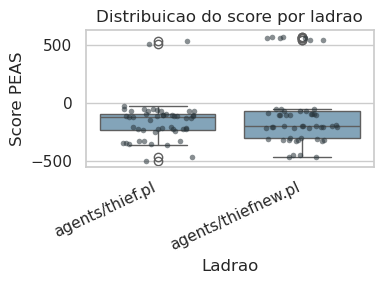

/home/lucas/dev/web/agents/tools/eval/results/cenario1__thief-thiefnew__vs__randomd__n50__seed1__184022daae76/figs/score_distribution_by_thief_agent.png


In [17]:
x_col, x_label = comparison_axis(matches)

plt.figure(figsize=FIGSIZE)
sns.boxplot(data=matches, x=x_col, y="score", color="#7aa6c2")
sns.stripplot(data=matches, x=x_col, y="score", color="#263238", alpha=0.55, jitter=0.25, size=4)
plt.title(f"Distribuicao do score por {x_label.lower()}")
plt.xlabel(x_label)
plt.ylabel("Score PEAS")
plt.xticks(rotation=25, ha="right")
save_fig(f"score_distribution_by_{x_col}.png")


## Taxa de vitoria

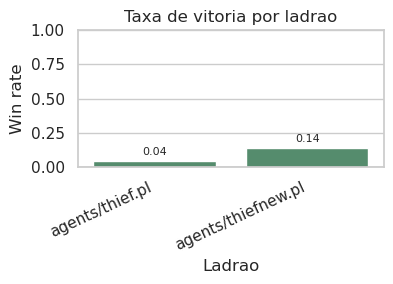

/home/lucas/dev/web/agents/tools/eval/results/cenario1__thief-thiefnew__vs__randomd__n50__seed1__184022daae76/figs/win_rate_by_thief_agent.png


In [18]:
data = without_all(summary).copy()
x_col, x_label = comparison_axis(data)

plt.figure(figsize=FIGSIZE)
ax = sns.barplot(data=data, x=x_col, y="win_rate", color="#4c956c")
plt.title(f"Taxa de vitoria por {x_label.lower()}")
plt.xlabel(x_label)
plt.ylabel("Win rate")
plt.ylim(0, 1)
ax.axhline(0, color="#333333", linewidth=0.8)

for idx, row in data.reset_index(drop=True).iterrows():
    value = float(row["win_rate"])
    label_y = value + 0.03 if value > 0 else 0.04
    ax.text(idx, label_y, f"{value:.2f}", ha="center", va="bottom", fontsize=8)
    if value == 0:
        ax.scatter([idx], [0], color="#4c956c", s=18, zorder=3)

plt.xticks(rotation=25, ha="right")
save_fig(f"win_rate_by_{x_col}.png")


## Resultados

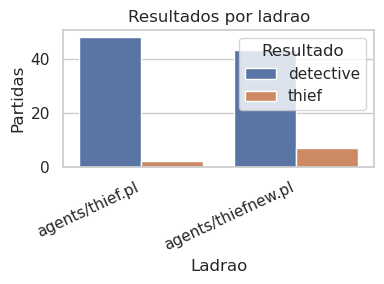

/home/lucas/dev/web/agents/tools/eval/results/cenario1__thief-thiefnew__vs__randomd__n50__seed1__184022daae76/figs/outcomes_by_thief_agent.png


In [19]:
x_col, x_label = comparison_axis(matches)
data = matches.groupby([x_col, "winner"]).size().reset_index(name="count")

plt.figure(figsize=FIGSIZE)
sns.barplot(data=data, x=x_col, y="count", hue="winner")
plt.title(f"Resultados por {x_label.lower()}")
plt.xlabel(x_label)
plt.ylabel("Partidas")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Resultado")
save_fig(f"outcomes_by_{x_col}.png")


## Score por rodada

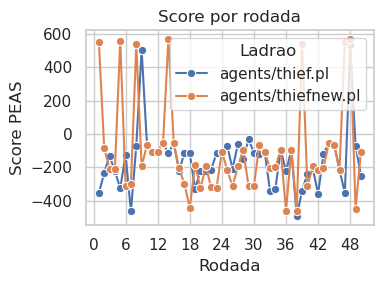

/home/lucas/dev/web/agents/tools/eval/results/cenario1__thief-thiefnew__vs__randomd__n50__seed1__184022daae76/figs/score_over_rounds.png


In [20]:
hue_col, hue_label = comparison_axis(matches)

plt.figure(figsize=FIGSIZE)
ax = sns.lineplot(data=matches, x="round", y="score", hue=hue_col, marker="o", errorbar=None)
plt.title("Score por rodada")
plt.xlabel("Rodada")
plt.ylabel("Score PEAS")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.legend(title=hue_label)
save_fig("score_over_rounds.png")


## Metricas medias

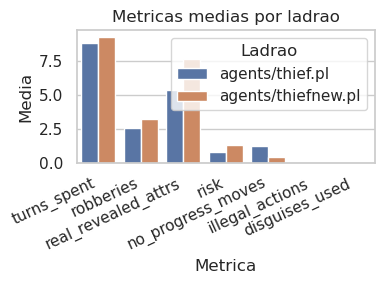

/home/lucas/dev/web/agents/tools/eval/results/cenario1__thief-thiefnew__vs__randomd__n50__seed1__184022daae76/figs/mean_metrics_by_thief_agent.png


In [21]:
metrics = [
    "turns_spent",
    "robberies",
    "real_revealed_attrs",
    "risk",
    "no_progress_moves",
    "illegal_actions",
    "disguises_used",
]
available = [col for col in metrics if col in matches.columns]

if available:
    group_col, group_label = comparison_axis(matches)
    melted = matches.melt(
        id_vars=[group_col],
        value_vars=available,
        var_name="metric",
        value_name="value",
    )

    plt.figure(figsize=FIGSIZE)
    sns.barplot(data=melted, x="metric", y="value", hue=group_col, estimator="mean", errorbar=None)
    plt.title(f"Metricas medias por {group_label.lower()}")
    plt.xlabel("Metrica")
    plt.ylabel("Media")
    plt.xticks(rotation=25, ha="right")
    plt.legend(title=group_label)
    save_fig(f"mean_metrics_by_{group_col}.png")


## Motivos de derrota

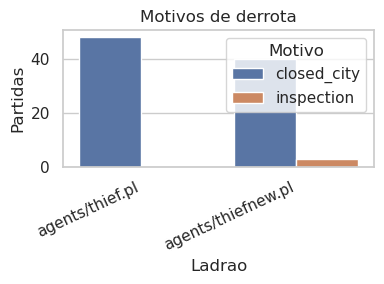

/home/lucas/dev/web/agents/tools/eval/results/cenario1__thief-thiefnew__vs__randomd__n50__seed1__184022daae76/figs/loss_reasons.png


In [22]:
data = matches[matches["loss_reason"].fillna("") != ""] if "loss_reason" in matches.columns else pd.DataFrame()

if not data.empty:
    x_col, x_label = comparison_axis(matches)
    counts = data.groupby([x_col, "loss_reason"]).size().reset_index(name="count")

    plt.figure(figsize=FIGSIZE)
    sns.barplot(data=counts, x=x_col, y="count", hue="loss_reason")
    plt.title("Motivos de derrota")
    plt.xlabel(x_label)
    plt.ylabel("Partidas")
    plt.xticks(rotation=25, ha="right")
    plt.legend(title="Motivo")
    save_fig("loss_reasons.png")


## Pior, media e melhor score

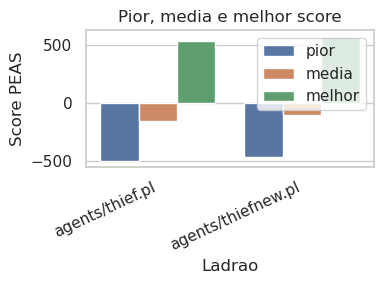

/home/lucas/dev/web/agents/tools/eval/results/cenario1__thief-thiefnew__vs__randomd__n50__seed1__184022daae76/figs/best_worst_scores.png


In [23]:
needed = {"detective_agent", "score_best", "score_mean", "score_worst"}

if needed.issubset(summary.columns):
    data = without_all(summary).copy()
    x_col, x_label = comparison_axis(data)
    data = data.melt(
        id_vars=[x_col],
        value_vars=["score_best", "score_mean", "score_worst"],
        var_name="kind",
        value_name="score",
    )
    data["kind"] = pd.Categorical(
        data["kind"],
        categories=["score_worst", "score_mean", "score_best"],
        ordered=True,
    )
    labels = {
        "score_worst": "pior",
        "score_mean": "media",
        "score_best": "melhor",
    }
    data["kind"] = data["kind"].map(labels)

    plt.figure(figsize=FIGSIZE)
    sns.barplot(data=data, x=x_col, y="score", hue="kind")
    plt.title("Pior, media e melhor score")
    plt.xlabel(x_label)
    plt.ylabel("Score PEAS")
    plt.xticks(rotation=25, ha="right")
    plt.legend(title="")
    save_fig("best_worst_scores.png")


## Score vs exposicao de pistas

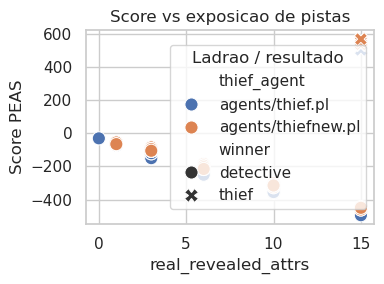

/home/lucas/dev/web/agents/tools/eval/results/cenario1__thief-thiefnew__vs__randomd__n50__seed1__184022daae76/figs/score_vs_exposure.png


In [24]:
x_col = "real_revealed_attrs" if "real_revealed_attrs" in matches.columns else "revealed_attrs_total"

if x_col in matches.columns:
    hue_col, hue_label = comparison_axis(matches)
    plt.figure(figsize=FIGSIZE)
    sns.scatterplot(data=matches, x=x_col, y="score", hue=hue_col, style="winner", s=90)
    plt.title("Score vs exposicao de pistas")
    plt.xlabel(x_col)
    plt.ylabel("Score PEAS")
    plt.legend(title=f"{hue_label} / resultado")
    save_fig("score_vs_exposure.png")
